In [1]:
import pandas as pd

df = pd.read_csv('Online_Retail.csv', encoding='ISO-8859-1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


In [2]:
df.shape

(541909, 8)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [4]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [5]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [6]:
# 看看退货记录长什么样（Quantity 为负）
df[df['Quantity'] < 0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/10 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/10 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/10 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/10 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/10 10:24,0.29,17548.0,United Kingdom


In [7]:
# 看看负价格的记录长什么样
df[df['UnitPrice'] < 0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,8/12/11 14:51,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,8/12/11 14:52,-11062.06,NaN,United Kingdom


In [8]:
# 记录原始行数，方便后面对比
print("清洗前总行数:", len(df))

# 把退货记录（InvoiceNo 以 C 开头）单独存起来，以防以后想分析
returns = df[df['InvoiceNo'].astype(str).str.startswith('C')]
print("退货记录数:", len(returns))

# 主数据里去掉退货记录，只保留正常销售
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
print("去掉退货后行数:", len(df))

清洗前总行数: 541909
退货记录数: 9288
去掉退货后行数: 532621


In [9]:
print("清洗前:", len(df))

df = df[df['UnitPrice'] > 0]

print("去掉异常价格后:", len(df))

清洗前: 532621
去掉异常价格后: 530104


In [10]:
print("清洗前:", len(df))

df = df.dropna(subset=['CustomerID'])

print("去掉缺失客户ID后:", len(df))

清洗前: 530104
去掉缺失客户ID后: 397884


In [11]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']
df[['Quantity', 'UnitPrice', 'Revenue']].head()

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [12]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['InvoiceDate'].head()

/var/folders/4_/zdn0wbys22ldvxyzk3_3fwx40000gn/T/ipykernel_2043/3283123493.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])


0   2010-12-01 08:26:00
1   2010-12-01 08:26:00
2   2010-12-01 08:26:00
3   2010-12-01 08:26:00
4   2010-12-01 08:26:00
Name: InvoiceDate, dtype: datetime64[ns]

In [13]:
df.to_csv('retail_clean.csv', index=False)
print("已保存,最终行数:", len(df))

已保存,最终行数: 397884


In [14]:
import sqlite3

conn = sqlite3.connect('retail.db')
df.to_sql('sales', conn, if_exists='replace', index=False)

# 验证一下导入成功了
test = pd.read_sql('SELECT * FROM sales LIMIT 5', conn)
test

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [15]:
query1 = """
SELECT Country, SUM(Revenue) as TotalRevenue
FROM sales
GROUP BY Country
ORDER BY TotalRevenue DESC
LIMIT 10
"""

result1 = pd.read_sql(query1, conn)
result1

,Country,TotalRevenue
0,United Kingdom,7308391.554
1,Netherlands,285446.340
2,EIRE,265545.900
3,Germany,228867.140
4,France,209024.050
5,Australia,138521.310
6,Spain,61577.110
7,Switzerland,56443.950
8,Belgium,41196.340
9,Sweden,38378.330


In [16]:
query2 = """
SELECT CustomerID, SUM(Revenue) as TotalRevenue
FROM sales
GROUP BY CustomerID
ORDER BY TotalRevenue DESC
LIMIT 10
"""

result2 = pd.read_sql(query2, conn)
result2

,CustomerID,TotalRevenue
0,14646.0,280206.02
1,18102.0,259657.30
2,17450.0,194550.79
3,16446.0,168472.50
4,14911.0,143825.06
5,12415.0,124914.53
6,14156.0,117379.63
7,17511.0,91062.38
8,16029.0,81024.84
9,12346.0,77183.60


In [17]:
query3 = """
SELECT Description, SUM(Revenue) as TotalRevenue
FROM sales
GROUP BY Description
ORDER BY TotalRevenue DESC
LIMIT 10
"""

result3 = pd.read_sql(query3, conn)
result3

,Description,TotalRevenue
0,"PAPER CRAFT , LITTLE BIRDIE",168469.60
1,REGENCY CAKESTAND 3 TIER,142592.95
2,WHITE HANGING HEART T-LIGHT HOLDER,100448.15
3,JUMBO BAG RED RETROSPOT,85220.78
4,MEDIUM CERAMIC TOP STORAGE JAR,81416.73
5,POSTAGE,77803.96
6,PARTY BUNTING,68844.33
7,ASSORTED COLOUR BIRD ORNAMENT,56580.34
8,Manual,53779.93
9,RABBIT NIGHT LIGHT,51346.20


In [18]:
query_count = """
SELECT COUNT(DISTINCT CustomerID) as TotalCustomers
FROM sales
"""
pd.read_sql(query_count, conn)

,TotalCustomers
0,4338


In [19]:
query_top20 = """
SELECT SUM(CustomerRevenue) as Top20PctRevenue
FROM (
    SELECT CustomerID, SUM(Revenue) as CustomerRevenue
    FROM sales
    GROUP BY CustomerID
    ORDER BY CustomerRevenue DESC
    LIMIT 868
) as top_customers
"""

top20_result = pd.read_sql(query_top20, conn)
top20_result

,Top20PctRevenue
0,6649437.461


In [20]:
query_total = """
SELECT SUM(Revenue) as TotalRevenue
FROM sales
"""

total_result = pd.read_sql(query_total, conn)
total_result


,TotalRevenue
0,8911407.904


In [21]:
pct = top20_result['Top20PctRevenue'][0] / total_result['TotalRevenue'][0] * 100
print(f"前20%的客户贡献了总收入的 {pct:.1f}%")

前20%的客户贡献了总收入的 74.6%


In [22]:
#公司的收入高度依赖一小撮核心客户,这部分人一旦流失,冲击会很大
#建议:应该给这批高价值客户设计专属的维护策略(比如 VIP 服务、专属折扣、优先客服),而不是把营销资源平均撒给所有客户
#同时也该关注这批人的留存情况——他们有没有流失的迹象?(这正好是我们下一步 RFM 分析要回答的问题)

In [23]:
import datetime as dt

# 数据里最晚的日期是哪天
latest_date = df['InvoiceDate'].max()
print("数据最后一天:", latest_date)

# 基准日 = 最后一天 + 1天,当作"今天"
snapshot_date = latest_date + dt.timedelta(days=1)
print("分析基准日:", snapshot_date)

数据最后一天: 2011-12-09 12:50:00
分析基准日: 2011-12-10 12:50:00


In [24]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                    # Frequency
    'Revenue': 'sum'                                           # Monetary
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [25]:
# 注意:Recency 是"越小越好"(天数少=最近买过),所以打分方向要反过来
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
CustomerID,,,,,,
12346.0,326,1,77183.60,1,1,5
12347.0,2,7,4310.00,5,5,5
12348.0,75,4,1797.24,2,4,4
12349.0,19,1,1757.55,4,1,4
12350.0,310,1,334.40,1,1,2


In [28]:
# 消费最高的5个客户
rfm.sort_values('Monetary', ascending=False).head()

# 最久没来的5个客户(潜在流失)
rfm.sort_values('Recency', ascending=False).head()

# 买得最勤的5个客户
rfm.sort_values('Frequency', ascending=False).head()

print("=== 消费最高的5个客户 ===")
display(rfm.sort_values('Monetary', ascending=False).head())

print("\n=== 最久没来的5个客户(潜在流失) ===")
display(rfm.sort_values('Recency', ascending=False).head())

print("\n=== 买得最勤的5个客户 ===")
display(rfm.sort_values('Frequency', ascending=False).head())

=== 消费最高的5个客户 ===


,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
CustomerID,,,,,,
14646.0,2,73,280206.02,5,5,5
18102.0,1,60,259657.30,5,5,5
17450.0,8,46,194550.79,5,5,5
16446.0,1,2,168472.50,5,3,5
14911.0,1,201,143825.06,5,5,5



=== 最久没来的5个客户(潜在流失) ===


,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
CustomerID,,,,,,
14729.0,374,1,313.49,1,1,2
17908.0,374,1,243.28,1,2,1
12791.0,374,1,192.60,1,1,1
13747.0,374,1,79.60,1,1,1
16583.0,374,1,233.45,1,2,1



=== 买得最勤的5个客户 ===


,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
CustomerID,,,,,,
12748.0,1,209,33719.73,5,5,5
14911.0,1,201,143825.06,5,5,5
17841.0,2,124,40991.57,5,5,5
13089.0,3,97,58825.83,5,5,5
14606.0,1,93,12156.65,5,5,5


In [29]:
# 曾经消费不低,但Recency已经拉开(比如超过90天没来)的客户
at_risk = rfm[(rfm['Monetary'] > 5000) & (rfm['Recency'] > 90)]
at_risk.sort_values('Monetary', ascending=False).head(10)

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
CustomerID,,,,,,
12346.0,326,1,77183.60,1,1,5
15749.0,235,3,44534.30,1,3,5
15098.0,182,3,39916.50,1,3,5
16180.0,100,8,10254.18,2,5,5
12590.0,211,2,9864.26,1,2,5
13093.0,276,8,7832.47,1,5,5
12980.0,158,9,7374.90,2,5,5
13027.0,114,6,6912.00,2,5,5
16553.0,163,12,5719.82,2,5,5


In [31]:
#我们识别出一批曾经消费金额可观(5,000–77,000 不等)、但已长期(90 天以上,部分超过一年)未产生购买行为的客户。
#这批人历史贡献了可观收入,但目前处于流失或已流失状态。
#建议对这批客户展开专项挽回动作(比如定向优惠、客户回访),优先级应高于对新客户的获取投入——挽回一个老客户的成本通常远低于获取一个新客户。

In [32]:
rfm['RFM_Score'] = rfm['R_Score'].astype(int) + rfm['F_Score'].astype(int) + rfm['M_Score'].astype(int)
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,
12346.0,326,1,77183.60,1,1,5,7
12347.0,2,7,4310.00,5,5,5,15
12348.0,75,4,1797.24,2,4,4,10
12349.0,19,1,1757.55,4,1,4,9
12350.0,310,1,334.40,1,1,2,4


In [33]:
def segment_customer(score):
    if score >= 13:
        return 'Champions 核心客户'
    elif score >= 10:
        return 'Loyal 忠实客户'
    elif score >= 7:
        return 'At Risk 流失预警'
    else:
        return 'Lost 已流失/低价值'

rfm['Segment'] = rfm['RFM_Score'].apply(segment_customer)
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
CustomerID,,,,,,,,
12346.0,326,1,77183.60,1,1,5,7,At Risk 流失预警
12347.0,2,7,4310.00,5,5,5,15,Champions 核心客户
12348.0,75,4,1797.24,2,4,4,10,Loyal 忠实客户
12349.0,19,1,1757.55,4,1,4,9,At Risk 流失预警
12350.0,310,1,334.40,1,1,2,4,Lost 已流失/低价值


In [34]:
segment_summary = rfm.groupby('Segment').agg(
    CustomerCount=('Monetary', 'count'),
    TotalRevenue=('Monetary', 'sum'),
    AvgRevenue=('Monetary', 'mean')
).sort_values('TotalRevenue', ascending=False)

segment_summary

,CustomerCount,TotalRevenue,AvgRevenue
Segment,,,
Champions 核心客户,934,6255336.530,6697.362452
Loyal 忠实客户,1008,1408629.911,1397.450309
At Risk 流失预警,1092,882612.662,808.253353
Lost 已流失/低价值,1304,364828.801,279.776688


In [ ]:
#收入高度集中在少数核心客户身上,21.5%的客户贡献了超过七成收入。
#运营资源应从"平均分配"转向"按客户价值分层配置"——重点保住 Champions、精准挽回 At Risk 中的高价值个体、对 Lost 组保持最低成本维系

In [35]:
import matplotlib.pyplot as plt

# 让中文能正常显示(如果你的标题用中文)
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

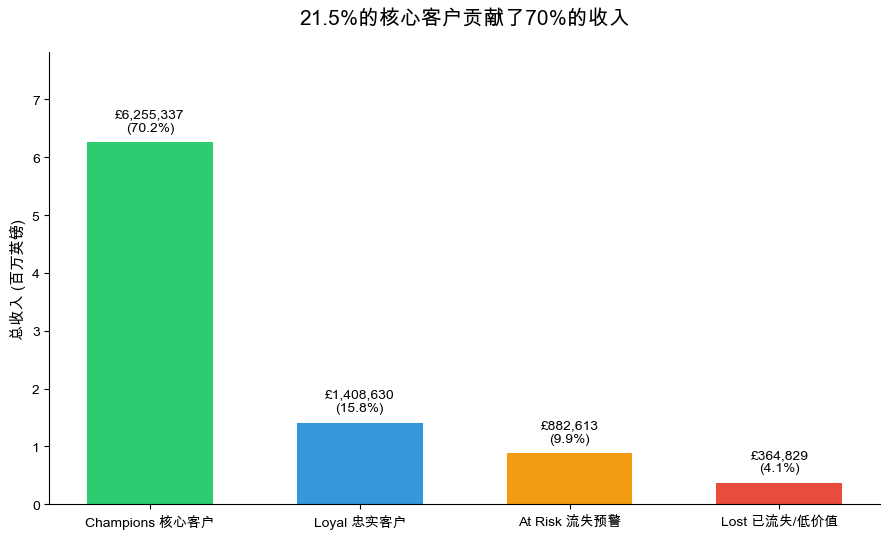

In [42]:
fig, ax = plt.subplots(figsize=(9, 5.5))

colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']
revenue_millions = segment_summary['TotalRevenue'] / 1_000_000

bars = ax.bar(segment_summary.index, revenue_millions, color=colors, width=0.6)

ax.set_title('21.5%的核心客户贡献了70%的收入', fontsize=15, fontweight='bold', pad=20)
ax.set_ylabel('总收入 (百万英镑)', fontsize=11)

total = segment_summary['TotalRevenue'].sum()
for bar, v in zip(bars, segment_summary['TotalRevenue']):
    pct = v / total * 100
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.15,
            f'£{v:,.0f}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(0, revenue_millions.max() * 1.25)

plt.tight_layout()
plt.savefig('chart1_segment_revenue.png', dpi=150, bbox_inches='tight')  # 新增:保存图片
plt.show()

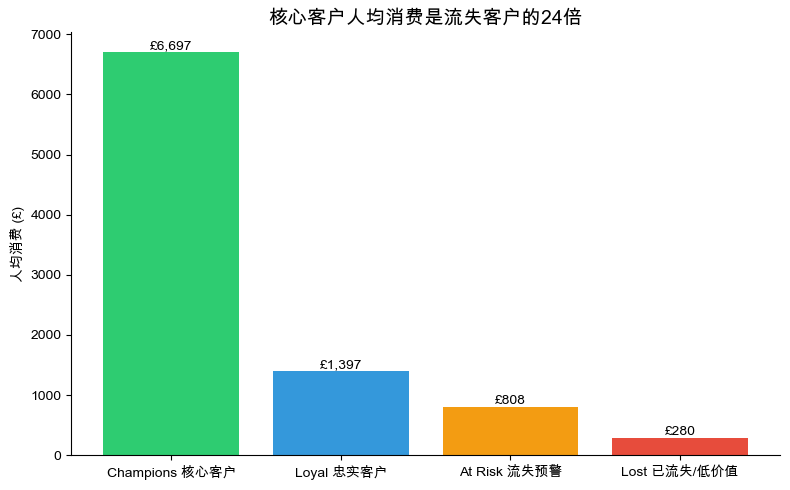

In [43]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(segment_summary.index, segment_summary['AvgRevenue'], color=colors)
ax.set_title('核心客户人均消费是流失客户的24倍', fontsize=14, fontweight='bold')
ax.set_ylabel('人均消费 (£)')

for i, v in enumerate(segment_summary['AvgRevenue']):
    ax.text(i, v, f'£{v:,.0f}', ha='center', va='bottom')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('chart2_avg_revenue.png', dpi=150, bbox_inches='tight')  # 新增:保存图片
plt.show()

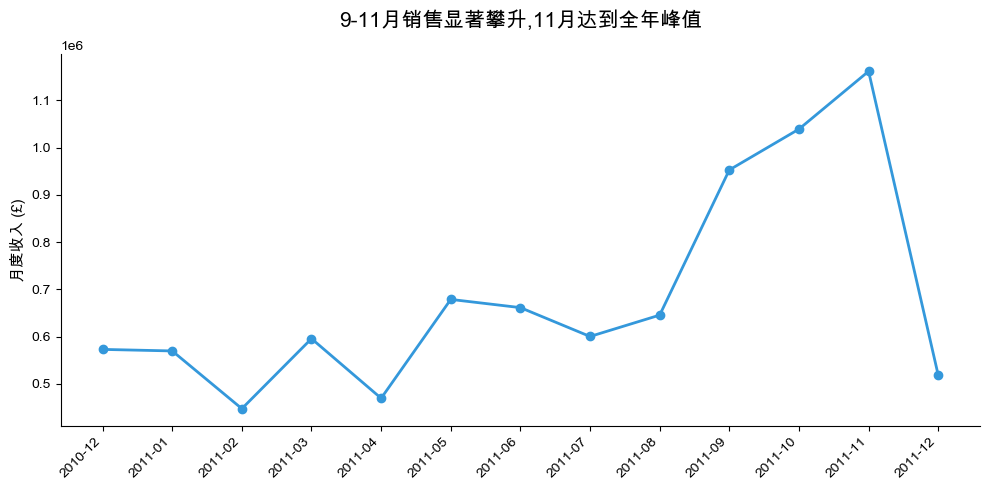

In [46]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(monthly_revenue.index.astype(str), monthly_revenue.values,
        marker='o', color='#3498db', linewidth=2)

ax.set_title('9-11月销售显著攀升,11月达到全年峰值', fontsize=15, fontweight='bold', pad=20)
ax.set_ylabel('月度收入 (£)', fontsize=11)
ax.set_xlabel('')

plt.xticks(rotation=45, ha='right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('chart3_monthly_trend.png', dpi=150, bbox_inches='tight')  # 新增:保存图片
plt.show()